# Dataset Source Check + Nearest-Neighbor Cosine Distance Diagnostic

Two independent diagnostics, combined into one standalone notebook:

1. **Dataset source check** -- confirms which CSI-Bench task subset (HAR/HID) and dataset
   root a given result JSON was produced from.
2. **NN cosine distance diagnostic** -- for `test_id` and `test_cross_env`, computes each
   sample's cosine distance to its nearest neighbor in `train_id`'s frozen embedding space,
   and plots the resulting distributions to check for a near-zero peak.

All paths below are written as explicit absolute paths (not derived from another
variable via string manipulation) -- update `BASE_DIR` if your project lives elsewhere;
everything else is built from it.

In [2]:
from pathlib import Path

BASE_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection")
RESULTS_DIR = BASE_DIR / "results"
CHECKPOINTS_DIR = BASE_DIR / "checkpoints"
FIG_DIR = BASE_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User",
}

In [3]:
from pathlib import Path
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")
for f in sorted((RESULTS_DIR / "mae_har").glob("*.json")):
    print(f.name)

finetune_mae_har_ep300_mask0.75_enc6_dim128_bs128_ep50.json
finetune_mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128_ep50.json
mae_har_ep300_mask0.5_strategyrandom_enc6_dim128_bs128.json
mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json
mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128.json
mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed43_enc12_dim128_bs128.json
mae_har_ep300_mask0.5_strategyrandom_ph29pw25_seed43_enc6_dim128_bs128.json
mae_har_ep300_mask0.625_strategyrandom_enc6_dim128_bs128.json
mae_har_ep300_mask0.75_enc6_dim128_bs128.json
mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128.json
mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed42_enc6_dim128_bs128.json
mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed43_enc12_dim128_bs128.json
mae_har_ep300_mask0.75_strategy2d_ph29pw25_seed43_enc6_dim128_bs128.json
mae_har_ep300_mask0.75_strategyfreq_ph29pw25_seed42_enc12_dim128_bs128.json
mae_har_

## Part 1 -- Dataset Source Check

In [4]:
import json
import sys

sys.path.insert(0, str(BASE_DIR))
import config

DATASET_CHECK_RESULT_JSON = RESULTS_DIR / "mae_har" / \
    "mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json"

with open(DATASET_CHECK_RESULT_JSON) as f:
    dataset_check_result = json.load(f)

exp_name = dataset_check_result["exp"]
task = "HumanActivityRecognition" if exp_name.startswith("mae_har") else \
       "HumanIdentification" if exp_name.startswith("mae_hid") else "UNKNOWN"

print(f"exp name:    {exp_name}")
print(f"task subset: CSI-Bench Multitask / {task}")
print(f"DATA_ROOT:   {config.DATA_ROOT}")
print(f"META_PATH:   {config.DATA_ROOT}/Multitask/{task}/metadata/sample_metadata.csv")
print(f"SPLITS_DIR:  {config.DATA_ROOT}/Multitask/{task}/splits")

exclude_devices = dataset_check_result["args"].get("exclude_devices", "")
if exclude_devices:
    print(f"NOTE: this run excluded device(s): {exclude_devices}")

exp name:    mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
task subset: CSI-Bench Multitask / HumanActivityRecognition
DATA_ROOT:   /home/zhuzih19/data/csi-bench-dataset
META_PATH:   /home/zhuzih19/data/csi-bench-dataset/Multitask/HumanActivityRecognition/metadata/sample_metadata.csv
SPLITS_DIR:  /home/zhuzih19/data/csi-bench-dataset/Multitask/HumanActivityRecognition/splits


## Part 2 -- Nearest-Neighbor Cosine Distance: test_id vs test_cross_env

Computes, for every sample in a given OOD split, the cosine distance to its nearest
neighbor in `train_id`'s frozen embedding space (`get_features()` output -- pooled
features, the same ones used by KNN/LP/MLP elsewhere in this project, NOT raw CSI).
Plots the resulting distributions for `test_id` vs `test_cross_env` side by side.

A near-zero peak in `test_id`'s distribution is expected (in-distribution samples should
sit close to `train_id` in embedding space). The diagnostic question is whether
`test_cross_env` shows the same near-zero peak (would suggest environment shift barely
moves the representation) or a clearly shifted distribution (would suggest the backbone
does separate environments in embedding space, consistent with the centroid-level
domain-shift geometry diagnostic already used elsewhere in this project).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

import torch
import pandas as pd

from data.dataset import MultiTaskDataset
from models.mae import MAE
from models.mae_v2 import MAEv2
from train.train_mae_har import (
    compute_padded_size, get_features, ENCODER_HEADS, RAW_IMG_H, RAW_IMG_W,
    META_PATH, SPLITS_DIR, DATA_ROOT, load_split,
)

In [6]:
def compute_min_cosine_distance(X_train, X_test):
    """
    Computes the minimum cosine distance from each sample in X_test
    to its nearest neighbor in X_train.

    Cosine Distance = 1 - Cosine Similarity
    """
    nn = NearestNeighbors(n_neighbors=1, metric='cosine', n_jobs=-1)
    nn.fit(X_train)
    distances, _ = nn.kneighbors(X_test)
    return distances.ravel()


def plot_nearest_cosine_dist_comparison(
    X_train,
    X_test_id,
    X_test_cross_env=None,
    X_test_device=None,
    outdir=None,
    filename="cosine_dist_comparison.png"
):
    """
    Computes nearest-neighbor cosine distances for test datasets
    and plots their histogram/KDE distribution.
    """
    results = {}
    near_zero_thresh = 0.05

    dist_id = compute_min_cosine_distance(X_train, X_test_id)
    results['id'] = dist_id
    print(f"[Diagnostic] test_id ratio with distance < {near_zero_thresh}: "
          f"{np.mean(dist_id < near_zero_thresh):.4f}")

    if X_test_cross_env is not None:
        dist_cross_env = compute_min_cosine_distance(X_train, X_test_cross_env)
        results['cross_env'] = dist_cross_env
        print(f"[Diagnostic] test_cross_env ratio with distance < {near_zero_thresh}: "
              f"{np.mean(dist_cross_env < near_zero_thresh):.4f}")

    if X_test_device is not None:
        dist_device = compute_min_cosine_distance(X_train, X_test_device)
        results['device'] = dist_device
        print(f"[Diagnostic] test_device ratio with distance < {near_zero_thresh}: "
              f"{np.mean(dist_device < near_zero_thresh):.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        dist_id, kde=True, stat="density", bins=50,
        color="tab:blue", alpha=0.35, label="test_id", ax=ax
    )

    if X_test_cross_env is not None:
        sns.histplot(
            results['cross_env'], kde=True, stat="density", bins=50,
            color="tab:orange", alpha=0.35, label="test_cross_env", ax=ax
        )

    if X_test_device is not None:
        sns.histplot(
            results['device'], kde=True, stat="density", bins=50,
            color="tab:green", alpha=0.35, label="test_device", ax=ax
        )

    ax.set_xlabel("Nearest Neighbor Cosine Distance to Train")
    ax.set_ylabel("Density")
    ax.set_title("Nearest Neighbor Cosine Distance Distribution")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if outdir is not None:
        fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")

    plt.show()

    return results

In [7]:
def build_model_for_diagnostic(train_args, padded_h, padded_w, device):
    common = dict(
        in_channels=1, img_h=padded_h, img_w=padded_w,
        patch_h=train_args['patch_h'], patch_w=train_args['patch_w'],
        encoder_dim=train_args['encoder_dim'], encoder_ff_dim=train_args['encoder_dim'] * 4,
        encoder_heads=ENCODER_HEADS, encoder_depth=train_args['encoder_depth'],
        decoder_dim=train_args['decoder_dim'], decoder_heads=2, decoder_depth=2,
        mask_ratio=train_args['mask_ratio'],
    )
    if train_args['mask_strategy'] == 'random':
        return MAE(**common).to(device)
    return MAEv2(**common, mask_strategy=train_args['mask_strategy']).to(device)


# -- Config: point these at the checkpoint/result you want to diagnose --------------
# Both paths are built directly from CHECKPOINTS_DIR / RESULTS_DIR (defined once, above)
# with exactly one "mae_har" segment -- not derived via string replacement, to avoid the
# duplicated-segment bug that a fragile str.replace()-based path would risk.
NN_DIAG_CHECKPOINT = CHECKPOINTS_DIR / "mae_har" / \
    "mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128_best.pt"
NN_DIAG_RESULT_JSON = RESULTS_DIR / "mae_har" / \
    "mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json"
NN_DIAG_LAYER = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open(NN_DIAG_RESULT_JSON) as f:
    nn_diag_result = json.load(f)
nn_diag_train_args = nn_diag_result['args']

nn_diag_padded_h = nn_diag_train_args.get('padded_h') or \
    compute_padded_size(RAW_IMG_H, nn_diag_train_args['patch_h'])
nn_diag_padded_w = nn_diag_train_args.get('padded_w') or \
    compute_padded_size(RAW_IMG_W, nn_diag_train_args['patch_w'])

nn_diag_model = build_model_for_diagnostic(nn_diag_train_args, nn_diag_padded_h, nn_diag_padded_w, device)
nn_diag_ckpt = torch.load(NN_DIAG_CHECKPOINT, map_location=device)
nn_diag_model.load_state_dict(nn_diag_ckpt['model_state'])
nn_diag_model.eval()
print(f"Loaded checkpoint: {nn_diag_result['exp']}, epoch={nn_diag_ckpt.get('epoch')}")

Loaded checkpoint: mae_har_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128, epoch=276


In [8]:
nn_diag_meta = pd.read_csv(META_PATH)
with open(f'{SPLITS_DIR}/train_id.json') as f:
    nn_diag_train_ids = set(json.load(f))
nn_diag_train_df = nn_diag_meta[nn_diag_meta['id'].isin(nn_diag_train_ids)].reset_index(drop=True)
nn_diag_label_map = {l: i for i, l in enumerate(sorted(nn_diag_train_df['label'].unique(), key=str))}

nn_diag_train_ds = MultiTaskDataset(nn_diag_train_df, DATA_ROOT, 'Multitask', label_map=nn_diag_label_map)

nn_diag_train_loader = torch.utils.data.DataLoader(nn_diag_train_ds, batch_size=128,
                                                    shuffle=False, num_workers=4)

nn_diag_test_id_loader = torch.utils.data.DataLoader(
    load_split('test_id', nn_diag_meta, nn_diag_label_map), batch_size=128, shuffle=False, num_workers=4)

nn_diag_test_cross_env_loader = torch.utils.data.DataLoader(
    load_split('test_cross_env', nn_diag_meta, nn_diag_label_map), batch_size=128, shuffle=False, num_workers=4)

nn_diag_test_cross_device_loader = torch.utils.data.DataLoader(
    load_split('test_cross_device', nn_diag_meta, nn_diag_label_map), batch_size=128, shuffle=False, num_workers=4)

X_train, _ = get_features(nn_diag_model, nn_diag_train_loader, NN_DIAG_LAYER, device,
                          nn_diag_padded_h, nn_diag_padded_w)
X_test_id, _ = get_features(nn_diag_model, nn_diag_test_id_loader, NN_DIAG_LAYER, device,
                            nn_diag_padded_h, nn_diag_padded_w)
X_test_cross_env, _ = get_features(nn_diag_model, nn_diag_test_cross_env_loader, NN_DIAG_LAYER, device,
                                   nn_diag_padded_h, nn_diag_padded_w)
X_test_cross_device, _ = get_features(nn_diag_model, nn_diag_test_cross_device_loader, NN_DIAG_LAYER, device,
                                     nn_diag_padded_h, nn_diag_padded_w)

X_train = X_train.numpy()
X_test_id = X_test_id.numpy()
X_test_cross_env = X_test_cross_env.numpy()
X_test_cross_device = X_test_cross_device.numpy()

print(f"X_train shape:          {X_train.shape}")
print(f"X_test_id shape:        {X_test_id.shape}")
print(f"X_test_cross_env shape: {X_test_cross_env.shape}")

X_train shape:          (21473, 128)
X_test_id shape:        (4602, 128)
X_test_cross_env shape: (6650, 128)


[Diagnostic] test_id ratio with distance < 0.05: 0.9998
[Diagnostic] test_cross_env ratio with distance < 0.05: 0.0412
[Diagnostic] test_device ratio with distance < 0.05: 0.0024


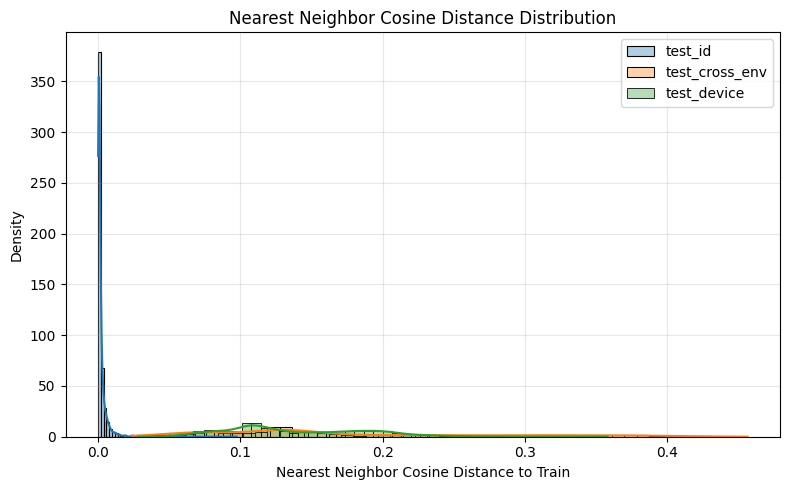

In [9]:
nn_diag_results = plot_nearest_cosine_dist_comparison(
    X_train, X_test_id, X_test_cross_env=X_test_cross_env, X_test_device=X_test_cross_device,
    outdir=FIG_DIR, filename=f"cosine_dist_comparison_layer{NN_DIAG_LAYER}.png"
)

In [10]:
import json
from pathlib import Path

# 1) 先看看 meta 里到底有哪些列
print("columns:", list(nn_diag_meta.columns))
print(nn_diag_meta.head(3))

# 2) 加载 test_id 的 id 列表
with open(f'{SPLITS_DIR}/test_id.json') as f:
    nn_diag_test_id_ids = set(json.load(f))

train_df = nn_diag_meta[nn_diag_meta['id'].isin(nn_diag_train_ids)]
test_df  = nn_diag_meta[nn_diag_meta['id'].isin(nn_diag_test_id_ids)]

print(f"train rows: {len(train_df)}, test rows: {len(test_df)}")

# 3) 对每一个可能区分录制段的列，检查 train/test 是否共享
#    列名按你数据实际有的改 —— 先看第 1 步打印出来的 columns
candidate_cols = ['session', 'session_id', 'recording', 'recording_id',
                  'subject', 'subject_id', 'user', 'user_id',
                  'env', 'environment', 'device', 'location']

for col in candidate_cols:
    if col in nn_diag_meta.columns:
        s_train = set(train_df[col].dropna())
        s_test  = set(test_df[col].dropna())
        shared  = s_train & s_test
        print(f"[{col}] train={len(s_train)} test={len(s_test)} shared={len(shared)}")
        if shared:
            print(f"    shared values (up to 10): {list(shared)[:10]}")

columns: ['id', 'file_path', 'subject', 'user', 'activity', 'distance', 'num_sub', 'environment', 'device', 'session', 'is_multi_subject', 'label']
                                          id  \
0  Human_U01_jumping_E01_AmazonPlug_56_16000   
1  Human_U01_jumping_E01_AmazonPlug_56_16001   
2  Human_U01_jumping_E01_AmazonPlug_56_16002   

                                           file_path subject user activity  \
0  ../../sub_Human_h5/user_U01/act_jumping/env_E0...   Human  U01  jumping   
1  ../../sub_Human_h5/user_U01/act_jumping/env_E0...   Human  U01  jumping   
2  ../../sub_Human_h5/user_U01/act_jumping/env_E0...   Human  U01  jumping   

   distance  num_sub environment      device  session  is_multi_subject  \
0       1.5       56         E01  AmazonPlug    16000             False   
1       1.5       56         E01  AmazonPlug    16001             False   
2       1.5       56         E01  AmazonPlug    16002             False   

     label  
0  jumping  
1  jumping  
2  jum

In [11]:
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path

DATA_ROOT = Path("/home/zhuzih19/data/csi-bench-dataset")
TASK = "HumanIdentification"   # change to "HumanActivityRecognition" for HAR

HID_META   = DATA_ROOT / "Multitask" / TASK / "metadata" / "sample_metadata.csv"
HID_SPLITS = DATA_ROOT / "Multitask" / TASK / "splits"

hid_meta = pd.read_csv(HID_META)
print("columns:", list(hid_meta.columns))
print("total rows:", len(hid_meta))
print()
print("first 5 ids:")
for x in hid_meta['id'].head(5):
    print("  ", x)
print()

with open(HID_SPLITS / "train_id.json") as f:
    hid_train_ids = set(json.load(f))
with open(HID_SPLITS / "test_id.json") as f:
    hid_test_ids = set(json.load(f))

hid_train_df = hid_meta[hid_meta['id'].isin(hid_train_ids)].reset_index(drop=True)
hid_test_df  = hid_meta[hid_meta['id'].isin(hid_test_ids)].reset_index(drop=True)

print(f"train rows : {len(hid_train_df)}")
print(f"test_id rows: {len(hid_test_df)}")

columns: ['id', 'file_path', 'subject', 'user', 'activity', 'distance', 'num_sub', 'environment', 'device', 'session', 'is_multi_subject', 'label']
total rows: 55684

first 5 ids:
   Human_U01_jumping_E01_AmazonPlug_56_16000
   Human_U01_jumping_E01_AmazonPlug_56_16001
   Human_U01_jumping_E01_AmazonPlug_56_16002
   Human_U01_jumping_E01_AmazonPlug_56_16003
   Human_U01_jumping_E01_AmazonPlug_56_16004

train rows : 21473
test_id rows: 4602


In [12]:
print("=" * 60)
print("Shared columns between train_id and test_id")
print("=" * 60)

for col in ['subject', 'user', 'environment', 'device', 'session', 'activity']:
    if col not in hid_meta.columns:
        continue
    s_train = set(hid_train_df[col].dropna())
    s_test  = set(hid_test_df[col].dropna())
    shared  = s_train & s_test
    flag = "  <-- LEAK" if (len(shared) > 0 and col != 'session') else ""
    print(f"[{col:12s}] train={len(s_train):5d}  test={len(s_test):5d}  shared={len(shared):5d}{flag}")
    if shared and col != 'session' and len(shared) <= 20:
        print(f"               shared values: {sorted(shared)}")

Shared columns between train_id and test_id
[subject     ] train=    1  test=    1  shared=    1  <-- LEAK
               shared values: ['Human']
[user        ] train=    6  test=    6  shared=    6  <-- LEAK
               shared values: ['U01', 'U03', 'U04', 'U05', 'U06', 'U22']
[environment ] train=    6  test=    6  shared=    6  <-- LEAK
               shared values: ['E01', 'E02', 'E03', 'E04', 'E06', 'E27']
[device      ] train=    8  test=    8  shared=    8  <-- LEAK
               shared values: ['AppleHomePod', 'EchoPlus', 'EchoShow', 'EightreePlug', 'GoogleNest', 'GoveePlug', 'HP', 'WyzePlug']
[session     ] train=21473  test= 4602  shared=    0
[activity    ] train=    5  test=    5  shared=    5  <-- LEAK
               shared values: ['jumping', 'running', 'seated-breathing', 'walking', 'wavinghand']


In [13]:
def extract_window_index(s):
    m = re.search(r'_(\d+)$', str(s))
    return int(m.group(1)) if m else None

def extract_recording_key(s):
    return re.sub(r'_\d+$', '', str(s))

hid_train_df['window_idx']    = hid_train_df['id'].apply(extract_window_index)
hid_test_df['window_idx']     = hid_test_df['id'].apply(extract_window_index)
hid_train_df['recording_key'] = hid_train_df['id'].apply(extract_recording_key)
hid_test_df['recording_key']  = hid_test_df['id'].apply(extract_recording_key)

print("=" * 60)
print("Recording-key level overlap")
print("=" * 60)
print(f"unique recording keys in train   : {hid_train_df['recording_key'].nunique()}")
print(f"unique recording keys in test_id : {hid_test_df['recording_key'].nunique()}")

shared_rec = set(hid_train_df['recording_key']) & set(hid_test_df['recording_key'])
print(f"shared recording keys            : {len(shared_rec)}")
print()

if shared_rec:
    print("Examples of shared recordings (the leak points):")
    for rk in sorted(shared_rec)[:5]:
        tr = hid_train_df[hid_train_df['recording_key'] == rk]['window_idx'].dropna()
        te = hid_test_df[hid_test_df['recording_key'] == rk]['window_idx'].dropna()
        print(f"  {rk}")
        print(f"    train window range: {int(tr.min())} .. {int(tr.max())}  (n={len(tr)})")
        print(f"    test  window range: {int(te.min())} .. {int(te.max())}  (n={len(te)})")

Recording-key level overlap
unique recording keys in train   : 341
unique recording keys in test_id : 340
shared recording keys            : 340

Examples of shared recordings (the leak points):
  Human_U01_jumping_E01_AppleHomePod_56
    train window range: 21000 .. 25013  (n=38)
    test  window range: 21013 .. 25010  (n=6)
  Human_U01_jumping_E01_EchoPlus_56
    train window range: 26001 .. 30013  (n=43)
    test  window range: 26000 .. 30010  (n=8)
  Human_U01_jumping_E01_EchoShow_56
    train window range: 31000 .. 35012  (n=41)
    test  window range: 31003 .. 34008  (n=3)
  Human_U01_jumping_E01_EightreePlug_56
    train window range: 41000 .. 45013  (n=38)
    test  window range: 41004 .. 45010  (n=9)
  Human_U01_jumping_E01_GoogleNest_56
    train window range: 46000 .. 50013  (n=37)
    test  window range: 46001 .. 50006  (n=9)


In [14]:
print("=" * 60)
print("Leakage summary")
print("=" * 60)

n_test = len(hid_test_df)
n_test_in_shared_rec = hid_test_df['recording_key'].isin(shared_rec).sum()

print(f"test_id samples whose recording also appears in train : "
      f"{n_test_in_shared_rec} / {n_test}  ({100*n_test_in_shared_rec/n_test:.2f}%)")

# For each shared recording, measure how interleaved the windows are.
# If train/test window indices alternate, that is window-level leakage.
interleaved = 0
for rk in shared_rec:
    tr = np.sort(hid_train_df[hid_train_df['recording_key'] == rk]['window_idx'].dropna().values)
    te = np.sort(hid_test_df[hid_test_df['recording_key'] == rk]['window_idx'].dropna().values)
    if len(tr) == 0 or len(te) == 0:
        continue
    # Count test windows that have a train neighbor within +/- 2 indices
    has_neighbor = 0
    tr_set = set(tr)
    for t in te:
        if any((t + d) in tr_set for d in (-2, -1, 1, 2)):
            has_neighbor += 1
    if has_neighbor > 0.5 * len(te):
        interleaved += 1

print(f"shared recordings with interleaved train/test windows: "
      f"{interleaved} / {len(shared_rec)}")
print()
print("If the interleaved count is high, this confirms window-level leakage:")
print("adjacent overlapping windows are being split across train and test_id.")

Leakage summary
test_id samples whose recording also appears in train : 4602 / 4602  (100.00%)
shared recordings with interleaved train/test windows: 340 / 340

If the interleaved count is high, this confirms window-level leakage:
adjacent overlapping windows are being split across train and test_id.


In [15]:
for split_name in ["test_cross_env", "test_cross_device", "test_cross_user"]:
    fp = HID_SPLITS / f"{split_name}.json"
    if not fp.exists():
        print(f"{split_name}: split file not found, skipping")
        continue

    with open(fp) as f:
        ids = set(json.load(f))
    df = hid_meta[hid_meta['id'].isin(ids)].copy()
    df['recording_key'] = df['id'].apply(extract_recording_key)
    shared = set(hid_train_df['recording_key']) & set(df['recording_key'])

    print(f"--- {split_name} ---")
    print(f"  rows: {len(df)}")
    if 'environment' in df.columns:
        print(f"  shared environments with train: "
              f"{sorted(set(hid_train_df['environment']) & set(df['environment']))}")
    if 'device' in df.columns:
        print(f"  shared devices with train: "
              f"{sorted(set(hid_train_df['device']) & set(df['device']))}")
    print(f"  shared recording keys with train: {len(shared)} / {df['recording_key'].nunique()}")
    print()

--- test_cross_env ---
  rows: 6650
  shared environments with train: []
  shared devices with train: ['AppleHomePod', 'EchoPlus', 'EchoShow', 'EightreePlug', 'GoogleNest', 'GoveePlug', 'HP', 'WyzePlug']
  shared recording keys with train: 0 / 80

--- test_cross_device ---
  rows: 9631
  shared environments with train: ['E01', 'E02', 'E03', 'E04', 'E06', 'E27']
  shared devices with train: []
  shared recording keys with train: 0 / 122

--- test_cross_user ---
  rows: 12109
  shared environments with train: ['E01']
  shared devices with train: ['AppleHomePod', 'EchoPlus', 'EchoShow', 'EightreePlug', 'GoogleNest', 'GoveePlug', 'HP', 'WyzePlug']
  shared recording keys with train: 0 / 80



In [16]:
import numpy as np

meta['split'] = np.where(meta['id'].isin(train_ids), 'train',
                  np.where(meta['id'].isin(test_ids), 'test', 'other'))

group_cols = ['user', 'activity', 'environment', 'device', 'num_sub']

total_adjacent = 0
crossing_adjacent = 0

for key, g in meta.groupby(group_cols):
    g = g[g['split'].isin(['train', 'test'])].sort_values('session')
    if len(g) < 2:
        continue
    sessions = g['session'].values
    splits = g['split'].values
    diffs = np.diff(sessions)
    same_recording = diffs == 1          # adjacent window pair, same continuous recording
    crosses_split = splits[:-1] != splits[1:]
    total_adjacent += same_recording.sum()
    crossing_adjacent += (same_recording & crosses_split).sum()

print(f"adjacent-window pairs (diff==1): {total_adjacent}")
print(f"of those, split across train/test: {crossing_adjacent} "
      f"({100*crossing_adjacent/max(total_adjacent,1):.2f}%)")

NameError: name 'meta' is not defined